In [ ]:
import numpy as np
import matplotlib.pyplot as plt
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*

# **Lab 9 - AE latent dynamics with SINDy (AE+SINDy)**

So far, when dealing with parametrized time-dependent problems, we treated the model parameters, $\boldsymbol{\mu}$, and the time variable, $t$, exactly the same. This resulted in purely black-box ROMs that are very efficient but potentially very "distant" from the physics of the system. To re-gain some physical intuition, one possibility is to impose a **dynamical structure at the latent level**.
</br>
</br>
Let us consider a parametrized dynamical system arising from the discretization of a time-dependent PDE,

$$\displaystyle\frac{\partial\mathbf{u}_{\boldsymbol{\mu}}}{\partial t}-\mathcal{L}_{\boldsymbol{\mu}}(\mathbf{u}_{\boldsymbol{\mu}})=0.$$

For simplicity, we shall restrict to autonomous systems, such as the one above. Leveraging either POD or autoencoders, we can come up with a suitable dimensionality reduction technique based on the encoder-decoder framework. That is, we assume to have at our disposal two networks (already trained)

$$\Psi':\mathbb{R}^{N_h}\to\mathbb{R}^{n},\quad\quad\Psi:\mathbb{R}^{n}\to\mathbb{R}^{N_{h}},$$

such that $\Psi(\Psi'(\mathbf{u}_{\boldsymbol{\mu},t}))\approx \mathbf{u}_{\boldsymbol{\mu},t}$ for all $\boldsymbol{\mu}$ and $t$, where $\mathbf{u}_{\boldsymbol{\mu},t}:=\mathbf{u}_{\boldsymbol{\mu}}(t)\in\mathbb{R}^{N_h}$.
</br>
</br>
Let $\mathbf{z}_{\boldsymbol{\mu}}(t):=\Psi'(\mathbf{u}_{\boldsymbol{\mu},t})$ be the latent representation of the solution at time $t$. It is straightforward to see that $\mathbf{z}_{\boldsymbol{\mu}}$ also obeys an evolution equation. In fact, by the chain rule (assume $\approx$ is $=$ for simplicity...!),</br></br>

$$\tag{1}\displaystyle\frac{\partial\mathbf{z}_{\boldsymbol{\mu}}}{\partial t}=J_{\Psi'}(\mathbf{u}_{\boldsymbol{\mu}})\frac{\partial\mathbf{u}_{\boldsymbol{\mu}}}{\partial t}=J_{\Psi'}(\mathbf{u}_{\boldsymbol{\mu}})\mathcal{L}_{\boldsymbol{\mu}}(\mathbf{u}_{\boldsymbol{\mu}})=J_{\Psi'}(\Psi(\mathbf{z}_{\boldsymbol{\mu}}))\mathcal{L}_{\boldsymbol{\mu}}(\Psi(\boldsymbol{\nu}_{\boldsymbol{\mu}})),$$
</br>
where $J_{\Psi'}$ is the Jacobian of $\Psi'$. Since $\mathbf{z}_{\boldsymbol{\mu}}(t)\in\mathbb{R}^{n}$ is very low-dimensional, this suggests the following strategy: given $\boldsymbol{\mu}$ we can initialize the FOM solution at time $t=0$ (costless), map it onto the latent space, evolve the dynamics there, and then bring our solution back with the decoder.
</br></br>
**Unfortunately**, this idea is not very practical as the RHS in the dynamical equation for $\mathbf{z}_{\boldsymbol{\mu}}$ is very involved and requires assembling FOM operators in order to be evaluated (thus, still very expensive...). To overcome this drawback, we resort to machine learning techniques for *dynamics discovery*. Simply put, given sample trajectories of $\mathbf{z}_{\boldsymbol{\mu}}$, these techniques allow to estimate a map</br></br>
$$F:\mathbb{R}^{n}\times\mathbb{R}^{p}\to\mathbb{R}^{n}$$
</br>
such that $\partial_t\mathbf{z}_{\boldsymbol{\mu}}\approx F(\mathbf{z}_{\boldsymbol{\mu}},\boldsymbol{\mu}).$ In practice, this allows us to replace the *true* RHS in Eq. (1) with the one *learned from data*, $F$.

Among several techniques available in the literature, today we shall focus on SINDy (Sparse Identification of Nonlinear Dynamics). While the official implementation of SINDy is available on PyPI (see $\textsf{pysindy}$), here we shall rely on a custom implementation. This will allow us to better grasp the ideas underlying SINDy and to customize certain aspects.

### **Test case**: 2D Burgers' equation

In [ ]:
# Downloading the dataset
import gdown
gdown.download(id = "1pttr43Mz78aZyATBMVbGvBXhHPM8Tf23", output = "burgers_data.npz", quiet=False)
mesh = fe.unitsquaremesh(50, 50)
Vh = fe.space(mesh, 'CG', 1)
clc()

data = np.load("burgers_data.npz")
mu, u = dv.tensor(data['mu'].reshape(-1, 1), data['u'])

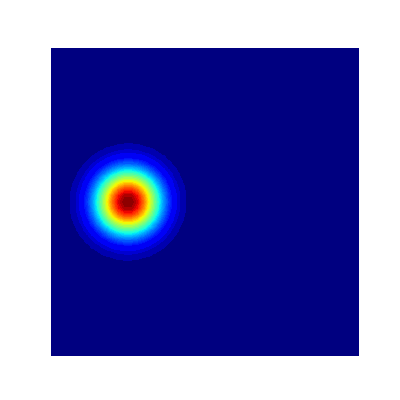

In [ ]:
fe.animate(u[0], Vh)

In [ ]:
ns, nt, nh = u.shape
p = mu.shape[-1]
print("Trajectories:\t%d." % ns)
print("Timesteps:\t%d." % nt)
print("FOM dimension:\t%d." % nh)
print("Parameters:\t%d." % p)

Trajectories:	50.
Timesteps:	51.
FOM dimension:	2601.
Parameters:	1.


### **Step 1.** Dimensionality reduction

To start, we shall construct and train a suitable autoencoder. We refrain from using POD as, here, our interest is to construct a latent representation that is as small as possible. In fact, if $n$ is too large, learning the dynamics of the latent variables can become troublesome.



In light of this, we opt for autoencoders. However, we don't "throw" POD away completely. Instead, we will use POD to enhance the autoencoder module (POD+AE).

<mark>**Exercise 1**</mark></br>
The code right below can be used to implement and train a POD+AE module. The latter is of the form $\mathbf{u}\approx\Psi(\Psi'(\mathbf{u}))$ where the encoder $\Psi':\mathbb{R}^{N_h}\to\mathbb{R}^n$ and the decoder $\Psi:\mathbb{R}^n\to\mathbb{R}^{N_h}$ are defined as

- $\Psi'(\mathbf{u}):=\psi'(\mathbf{V}^\top\mathbf{u})$ with $\psi':\mathbb{R}^{n_r}\to\mathbb{R}^{n}$

- $\Psi(\mathbf{z}):=\mathbf{V}\psi(\mathbf{z})$ with $\psi:\mathbb{R}^{n}\to\mathbb{R}^{n_r}$


where $\mathbf{V}\in\mathbb{R}^{N_h\times n_r}$ is a POD matrix featuring $n_r$ modes. The POD is used to establish a first compression phase, which is then prolonged by the "small" autoencoder $\psi\circ\psi'$.


Inspect the code, trying to understand how it is organized and how it operates (which latent dimension $n$ is being used?). Then, fill the missing parts.

In [ ]:
l2 = L2(Vh)
l2.cuda()
clc()

def error(utrue, upred):
    return (l2(utrue-upred).reshape(-1, nt).sum(axis = -1)/l2(utrue).reshape(-1, nt).sum(axis = -1)).mean()

In [ ]:
from scipy.linalg import svd
u = u.reshape(-1, nh)
ntrain = (ns//2)*nt

nr = 50
V = dv.tensor(svd(u[:ntrain].T.cpu().numpy(), full_matrices = False)[0][:, :nr]) ### <--- POD basis for POD-AE
ur = u @ V

In [ ]:
from torch import tanh
rho = lambda x: tanh(0.01*x) ### <-- smooth activation that bounds the dynamics within [-1,1]^n

latent = 2
small_encoder = Dense(nr, 20, gelu) + Dense(20, latent, rho)
small_decoder = Dense(latent, 20, gelu) + Dense(20, 40, gelu) + Dense(40, nr, activation = None)
small_ae = DFNN(small_encoder + small_decoder) ### <--- inner AE module, combining the "small encoder" and "small decoder"

small_ae.unfreeze()
small_ae.He()
small_ae.cuda()
small_ae.train(ur, ur, loss = mse(euclidean), ntrain = ntrain, epochs = 200)
small_ae.freeze()

		Train		Test
Epoch 200:	9.61e-03	8.95e-03.

>> ETA: 0.31s.

Training complete. Elapsed time: 1 minutes 2.13 seconds.


In [ ]:
from dlroms.dnns import Matrix

encoder = Matrix(V.T) + small_encoder
decoder = small_decoder + Matrix(V)
ae = encoder + decoder

In [ ]:
print("Autoencoder MRE: %s" % num2p(error(u[ntrain:], ae(u[ntrain:]))))

Autoencoder MRE: 0.44%


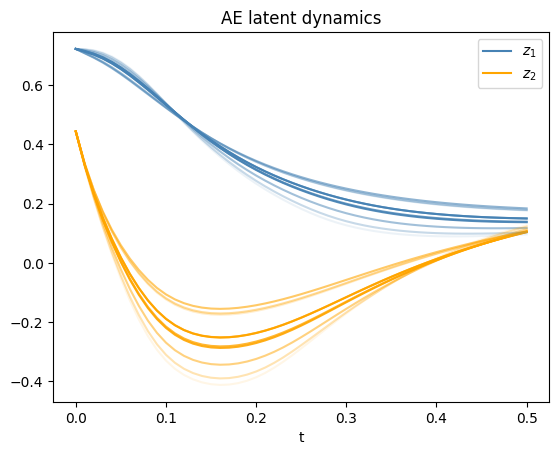

In [ ]:
z =  encoder(u) ### <--- latent representation of the solutions
t = np.arange(nt)*1e-2

for i in range(10):
  plot(t, z.reshape(-1, nt, latent)[i][:, 0], color = 'steelblue', alpha = 1.0 - i/10, label = '$z_1$' if i==0 else None)
  plot(t, z.reshape(-1, nt, latent)[i][:, 1], color = 'orange', alpha = 1.0 - i/10, label = '$z_2$' if i==0 else None)

plt.legend()
plt.xlabel("t")
plt.title("AE latent dynamics")
None

### **Step 2.** Dynamics discovery using (parametric) SINDy

As a second step, we aim to construct a SINDy model that can replicate the latent dynamics induced by the autoencoder. To this end, we shall implement a parametric variant of SINDy defined as follows.

- The first ingredient is the library $\Xi=[f_1,\dots, f_m]$ consisting of $m$ functions $f_i=f_i(\mathbf{z})$. The library will serve to compute the candidate terms appearing in the evolution equation;

- The second ingredient is a neural network model $\eta:\mathbb{R}^p\to\mathbb{R}^{n\times m}$. The latter will be used to predict the dynamics coefficients associated to each parametric configuration.

Given these two ingredients, parametric SINDy will propose the following equations for the latent dynamics

$$\partial_t\mathbf{z}_{\boldsymbol{\mu}}=\mathbf{A}_{\boldsymbol{\mu}}\Xi(\mathbf{z}),$$

where $\mathbf{A}_{\boldsymbol{\mu}}:=\eta(\boldsymbol{\mu})$ is the parametric matrix describing the dynamics.

While the library $\Xi$ has to be defined apriori, the network $\eta$ needs to be learned from data. In practice, this is achieved by relying on a loss function that matches the predicted time-derivatives with the "true" ones.

According to the SINDy paradigm, the loss function also features an additional term that promotes sparsity. In this way, only a few terms of the library will survive the process, leaving us with a compact and interpretable model.

<mark>**Exercise 2**</mark></br>
The code right below implements a parametric SINDy model for the latent dynamics.

Explore the code and fill the missing parts. Which library is being used (i.e., what is $\Xi$)?

How is the sparsity being promoted?

In [ ]:
from dlroms.dnns import Weightless
from torch import matmul

class Library(Weightless):
  def __init__(self, lib):
    super(Library, self).__init__()
    self.lib = lib

  def forward(self, x):
    from torch import cat
    nx = len(x)
    return cat([f(x).reshape(nx, -1) for f in self.lib], axis = -1)

class SINDy(ROM):
  def __init__(self, *args, **kwargs):
    from torch.nn import Parameter
    super(SINDy, self).__init__(*args, **kwargs)
    self.thr = Parameter(dv.tensor(0.0))

  def threshold(self, A0):
    # Hard-promotes sparsity by clamping values close to 0 (with a learnable threshold)
    return relu(A0-self.thr) - relu(-A0-self.thr)

  def A(self, mu):
    eta = self[0]
    A0 = eta(mu)
    return self.threshold(A0)

  def forward(self, mu, z):
    A = self.A(mu)
    theta = self.Xi(z).unsqueeze(-1)
    return matmul(A, theta).squeeze(-1), A

  def freeze(self, *args, **kwargs):
    super(SINDy, self).freeze(*args, **kwargs)
    self.thr.requires_grad_(False)

  def unfreeze(self, *args, **kwargs):
    super(SINDy, self).freeze(*args, **kwargs)
    self.thr.requires_grad_(True)

  def evolve(self, mu0, z0, steps, tau):
    from torch import atleast_2d
    mu0s = atleast_2d(mu0)
    z0s = atleast_2d(z0)

    many, n = z0s.shape
    zsindy = self.coretype().zeros(many, steps + 1, n)
    zsindy[:, 0] = z0s
    for j in range(steps):
      dzdtj = self.forward(mu0s, zsindy[:, j])[0]
      zsindy[:, j+1] = zsindy[:, j] + tau*dzdtj

    return zsindy

  def parameters(self, *args, **kwargs):
    return super(SINDy, self).parameters() + [self.thr]

  def He(self, *args, **kwargs):
    from torch.nn import Parameter
    super(SINDy, self).He(*args, **kwargs)
    self.thr = Parameter(dv.tensor(0.0))

In [ ]:
def dt(zval):
  """Approximation of time derivatives via finite differences.
  Later used in the definition of the loss to approximate the true derivatives."""
  tau = 1e-2
  zprev = zval.reshape(-1, nt, latent)[:, :-2, :].reshape(-1, latent)
  znext = zval.reshape(-1, nt, latent)[:, 2: ,  :].reshape(-1, latent) ### <--- latent state at time instant "i+1", for each sample in the batch
  dzdt = (znext-zprev)/(2*tau)
  return dzdt

In [ ]:
from dlroms.dnns import Reshape
Xi = Library([lambda x: x, lambda x: x**2, lambda x: x[:, 0]*x[:, 1], lambda x: x**3, lambda x: 1.0 + 0*x])

m = Xi(dv.zeros(1, latent)).shape[-1]
p = mu.shape[-1]

eta = Dense(p, 50, gelu) + Dense(50, 50, gelu) + Dense(50, m*latent, None) + Reshape(latent, m)
sindy = SINDy(eta, Xi = Xi)
sindy.He()
sindy.cuda()

In [ ]:
from torch.optim import Adam
def sindy_loss(ztrue, sindy_output):
  dzpred, A = sindy_output
  dzdt_true = dt(ztrue) ### <-- time derivatives of the true latent coordinates
  return mse(euclidean)(dzdt_true, dzpred.reshape(-1, nt, latent)[:, 1:-1].reshape(-1, latent)) + 0.01*A.abs().tanh().sum(axis = -1).sum(axis = -1).mean() # promotes sparsity via l1-penalty

def sindy_error(ztrue, sindy_output):
  dzpred, A = sindy_output
  dzdt_true = dt(ztrue) ### <-- time derivatives of the true latent coordinates
  return mse(euclidean)(dzdt_true, dzpred.reshape(-1, nt, latent)[:, 1:-1].reshape(-1, latent))

mu_repeated = (dv.zeros(ns, nt, 1) + mu.reshape(ns, 1, -1)).reshape(ns*nt, -1) ### <--- transforming [mu0, mu1, mu2, ...] onto [mu0, .., mu0, mu1, ... mu1, mu2, ....] for shape consistency with z
sindy.train((mu_repeated, z), z, loss = sindy_loss, error = sindy_error, epochs = 50, ntrain = ntrain)
sindy.train((mu_repeated, z), z, loss = sindy_loss, error = sindy_error, epochs = 500, ntrain = ntrain, optim = Adam, lr = 1e-3, batchsize = nt, shuffle = False)

		Train		Test
Epoch 500:	1.23e-02	1.16e-02.

>> ETA: 0.08s.

Training complete. Elapsed time: 39.30 seconds.


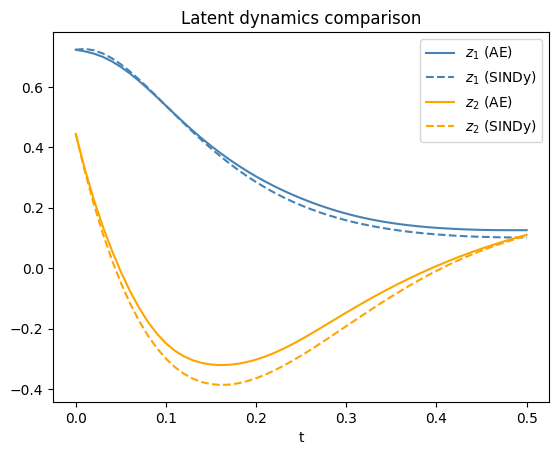

In [ ]:
sindy.freeze()

ztrue = encoder(u).reshape(-1, nt, latent)
z0s = ztrue[:, 0]
zsindy = sindy.evolve(mu_repeated.reshape(ns, nt, -1)[:, 0], z0s, steps = nt-1, tau = 1e-2)

which = -1
plot(t, ztrue[which, :, 0], color = 'steelblue', label = '$z_1$ (AE)')
plot(t, zsindy[which, :, 0], '--', color = 'steelblue', label = '$z_1$ (SINDy)')
plot(t, ztrue[which, :, 1], color = 'orange', label = '$z_2$ (AE)')
plot(t, zsindy[which, :, 1], '--', color = 'orange', label = '$z_2$ (SINDy)')
plt.legend()
plt.xlabel("t")
plt.title("Latent dynamics comparison")
None

In [ ]:
print("AE MRE: %s" % num2p(error(u[ntrain:], ae(u[ntrain:]))))
print("AE + SINDy MRE: %s" % num2p(error(u[ntrain:], decoder(zsindy.reshape(ns*nt, -1)[ntrain:])))) ### <--- AE + SINDy approximations obtained by decoding sindy evolved states

AE MRE: 0.44%
AE + SINDy MRE: 6.59%


### **Step 3.** Autoencoder + SINDy

Ideally, the autoencoder module and the SINDy block should be learned all together. This, in fact, would ensure that the autoencoder si finding a "regular" latent space, where the dynamics is more or less aligned with the one predicted by SINDy. Here, we shall combine the two pieces, starting from what we implemented so far. From there, we will proceed with a "final training phase", aiming at improving the accuracy of the whole ROM.

<mark>**Exercise 3**</mark></br>
The code right below combines the trained AE and the SINDy block, and re-optimizes them jointly.

Inspect the code and fill the missing parts.

In [ ]:
class AESINDy(ROM):
  def forward(self, mut, u):
    encoder = self[0]
    decoder = self[1]
    sindy = self[2]

    z = encoder(u)
    dzdt_encoder = dt(z)

    sindy_output = sindy(mut, z)
    dzdt_sindy = sindy_output[0].reshape(-1, nt, latent)[:, 1:-1].reshape(-1, latent)
    A_sindy = sindy_output[1]

    u_ae = decoder(z)

    return dzdt_encoder, dzdt_sindy, u_ae, A_sindy

In [ ]:
ae_sindy = AESINDy(small_encoder, small_decoder, sindy)
ae_sindy.save("ae_sindy.npz")

In [ ]:
def ae_sindy_loss(utrue, predictions):
  dzdt_encoder, dzdt_sindy, u_ae, A = predictions
  sindy_loss = mse(euclidean)(dzdt_encoder, dzdt_sindy) + 0.01*A.abs().tanh().sum(axis = -1).sum(axis = -1).mean()
  ae_loss = mse(euclidean)(utrue, u_ae)
  return sindy_loss + ae_loss

def ae_sindy_error(utrue, predictions):
  _, _, u_ae, _ = predictions ### <--- extracting only AE reconstructions (third output of AE+SINDy)
  return mse(euclidean)(utrue, u_ae)

In [ ]:
from torch.optim import Adam
ae_sindy.load("ae_sindy.npz")
ae_sindy.unfreeze()

ae_sindy.train((mu_repeated, ur), ur, ntrain = ntrain, epochs = 2000, optim = Adam, lr = 1e-3,
               loss = ae_sindy_loss, error = ae_sindy_error, shuffle = False, batchsize = nt)

		Train		Test
Epoch 2000:	8.37e-03	7.96e-03.

>> ETA: 0.12s.

Training complete. Elapsed time: 3 minutes 55.55 seconds.


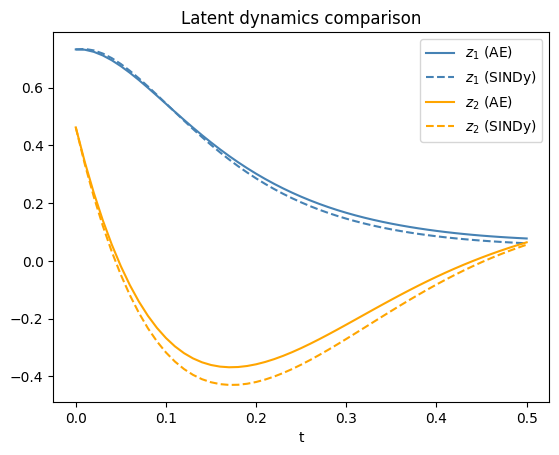

In [ ]:
ae_sindy.freeze()
ztrue = encoder(u).reshape(-1, nt, latent)
z0s = ztrue[:, 0]
zsindy = ae_sindy[-1].evolve(mu_repeated.reshape(ns, nt, -1)[:, 0], z0s, steps = nt-1, tau = 1e-2)

which = -1
plot(t, ztrue[which, :, 0], color = 'steelblue', label = '$z_1$ (AE)')
plot(t, zsindy[which, :, 0], '--', color = 'steelblue', label = '$z_1$ (SINDy)')
plot(t, ztrue[which, :, 1], color = 'orange', label = '$z_2$ (AE)')
plot(t, zsindy[which, :, 1], '--', color = 'orange', label = '$z_2$ (SINDy)')
plt.legend()
plt.xlabel("t")
plt.title("Latent dynamics comparison")
None

In [ ]:
usindy = decoder(zsindy.reshape(ns*nt, -1)) ### <--- AE + SINDy approximations obtained by decoding sindy evolved states

In [ ]:
print("AE MRE: %s" % num2p(error(u[ntrain:], ae(u[ntrain:]))))
print("AE + SINDy MRE: %s" % num2p(error(u[ntrain:], usindy[ntrain:])))

AE MRE: 0.43%
AE + SINDy MRE: 5.89%


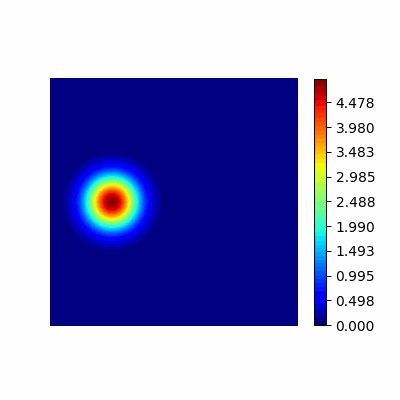

In [ ]:
fe.animate(u.reshape(ns, nt, -1)[which], Vh, colorbar = True)

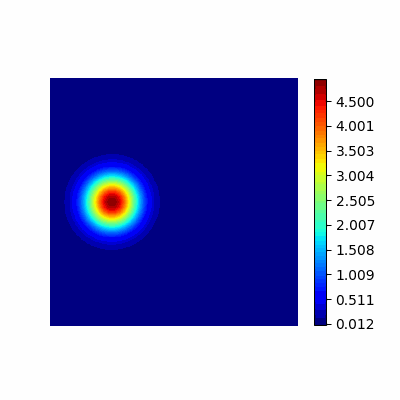

In [ ]:
fe.animate(usindy.reshape(ns, nt, -1)[which], Vh, colorbar = True)

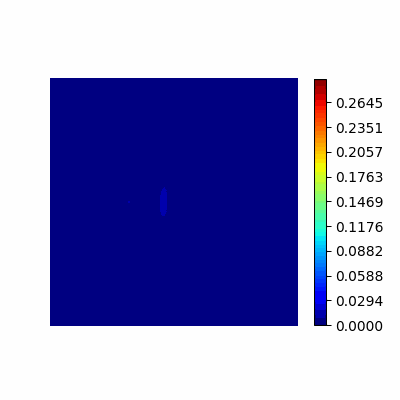

In [ ]:
fe.animate((u-usindy).abs().reshape(ns, nt, -1)[which], Vh, colorbar = True)